# GPELab simulation results:
## Plot energy and spin fractions for different values of $\Omega$

I plot there the result of a simulation of test (with papameters not yet optimized for for fitting the data).

Parameters of the test simulation:<br>
$a_{11}$ = (86.4014 * a_bohr); <br>
$a_{22}$ = (33.2021 * a_bohr);<br>
$a_{12}$ = (-53.1907 * a_bohr);<br>

$n_{1D}$ = 2.7e9;

$\omega_r$ = 169 * (2 pi) #Hz <br>
$\omega_z$ = 26 * (2 pi) #Hz

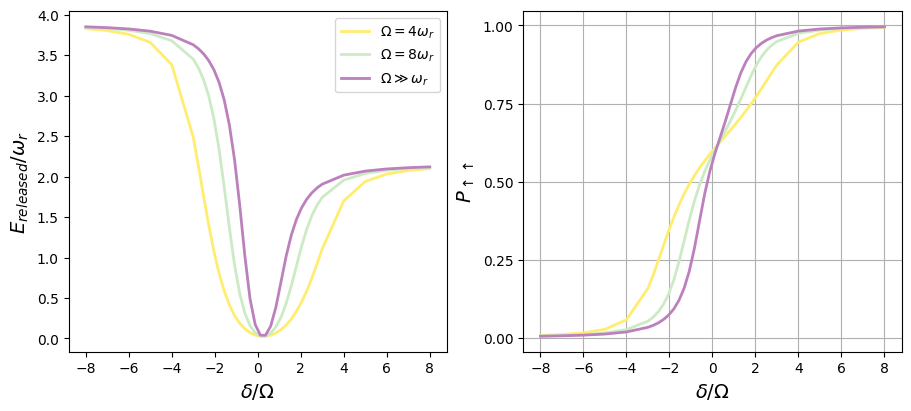

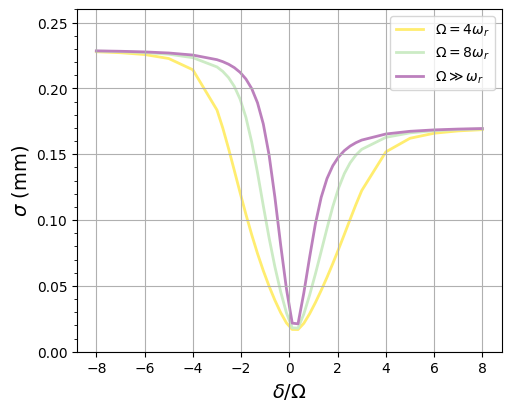

In [45]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.io

mat = scipy.io.loadmat(r'C:\Users\sarat\OneDrive\Documenti\InstOptique\Simulations\GPELab\outputs\results\25-02-17\output_data.mat')
delta_values = mat.get('delta_values').squeeze()
Omega_values = mat.get('Omega_values').squeeze()
P_down  = mat.get('P_down')
IE = mat.get('IE')
KE = mat.get('KE')
RE = mat.get('RE')
PE = mat.get('PE')
e_tot = mat.get('energy_tot')
 
sizeBEC = np.zeros_like(e_tot)

wr = 169*2*np.pi #Hz
wz = 26*2*np.pi  #Hz

u = 1.66053906660e-27
m = 39*u
hbar = 1.054571818e-34 #J s


#%% plots
colors = plt.get_cmap('Set3_r').colors
lw = 2

labels = [r'$\Omega = 4\omega_r$', r'$\Omega = 8\omega_r$', r'$\Omega \gg \omega_r$']
# Plotting the expressions
fig, ax = plt.subplots(1,2,constrained_layout=True, figsize=(9,4))


for i in range(np.size(Omega_values)):
    Om = Omega_values[i]
    
    e_rel = (e_tot[i,:]-RE[i,:])*Om/wr -1
    ax[0].plot(delta_values.T, e_rel, label=labels[i], lw=lw, color=colors[i])
    ax[1].plot(delta_values.T,P_down[i,:], lw=lw, color=colors[i])

ax[0].set_xlabel(r'$\delta/\Omega$', fontsize=14)
ax[0].set_ylabel(r'$E_{released}/\omega_r$',fontsize = 14)
ax[0].legend()

yticks = np.linspace(0,1,5)
ytick_labels = [r'$0$', r'$0.25$', r'$0.5$', r'$0.75$' , r'$1$']
ax[1].set_yticks(yticks)
ax[1].set_xlabel(r'$\delta/\Omega$', fontsize=14)
ax[1].set_ylabel(r'$P_{\uparrow\uparrow}$',fontsize = 14)
ax[1].grid()


#%% size after tof
from matplotlib.ticker import AutoMinorLocator, MultipleLocator

figS, axS = plt.subplots(1,1,constrained_layout=True, figsize=(5,4))

for i in range(np.size(Omega_values)):
    Om = Omega_values[i]
    t_tof = 62.6e-3  #s
    
    e_rel = (IE[i,:]+KE[i,:]+PE[i,:])*(hbar*Om) - hbar*wr # energy tot - Rabi energy - hbar * wr
    v = np.sqrt(2*e_rel/m)   
    sizeBEC[i,:] = v * t_tof
    
    axS.plot(delta_values.T, sizeBEC[i,:]*10**3, label=labels[i], lw=lw, color=colors[i],zorder =1)
    
axS.set_xlabel(r'$\delta/\Omega$', fontsize=14)
axS.set_ylabel(r'$\sigma$ (mm)',fontsize = 14)  
axS.set_ylim(0,0.26)  
axS.yaxis.set_major_locator(MultipleLocator(0.05))
axS.yaxis.set_major_formatter('{x:.2f}')
axS.yaxis.set_minor_locator(MultipleLocator(0.01))
axS.legend()
axS.grid()

## Plot energy dcomposition for one single curve (low Omega)

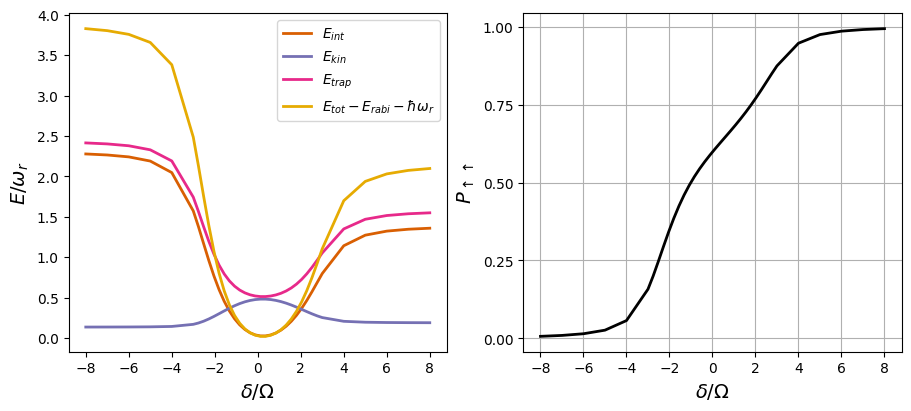

In [8]:
# select the curve
i = 0
Om = Omega_values[i]

wr = 169*2*np.pi #Hz
wz = 26*2*np.pi  #Hz

#%%
colors = plt.get_cmap('Set3').colors
colors2 = plt.get_cmap('Dark2').colors
lw = 2

labels = [r'$\Omega = 4\omega_r$', r'$\Omega = 8\omega_r$', r'$\Omega \gg \omega_r$']
# Plotting the expressions
fig, ax = plt.subplots(1,2,constrained_layout=True, figsize=(9,4))

ax[0].plot(delta_values.T, IE[i,:]*Om/wr, label=r"$E_{int}$", lw=lw, color=colors2[1])
ax[0].plot(delta_values.T, KE[i,:]*Om/wr, label=r'$E_{kin}$', lw=lw, color=colors2[2])
ax[0].plot(delta_values.T, PE[i,:]*Om/wr, label=r'$E_{trap}$', lw=lw, color=colors2[3])
ax[0].plot(delta_values.T, (IE[i,:]+KE[i,:]+PE[i,:])*Om/wr - 1, label=r'$E_{tot}-E_{rabi}-\hbar\omega_r$', lw=lw, color=colors2[5])
ax[1].plot(delta_values.T,P_down[i,:], lw=lw, color='black')

ax[0].set_xlabel(r'$\delta/\Omega$', fontsize=14)
ax[0].set_ylabel(r'$E/\omega_r$',fontsize = 14)
ax[0].legend()

yticks = np.linspace(0,1,5)
ytick_labels = [r'$0$', r'$0.25$', r'$0.5$', r'$0.75$' , r'$1$']
ax[1].set_yticks(yticks)
ax[1].set_xlabel(r'$\delta/\Omega$', fontsize=14)
ax[1].set_ylabel(r'$P_{\uparrow\uparrow}$',fontsize = 14)
ax[1].grid()

# Simulation parameters to best fit the data:

I plot there the result of a simulation of test (with papameters not yet optimized for for fitting the data).

Parameters of the test simulation:<br>
$a_{11}$ = (86.4014 * a_bohr); <br>
$a_{22}$ = (33.2021 * a_bohr);<br>
$a_{12}$ = (-53.1907 * a_bohr);<br>

$n_{1D}$ = 4.6e9;

$\omega_r$ = 169 * (2 pi) #Hz <br>
$\omega_z$ = 26 * (2 pi) #Hz

## Integration over a Thomas-Fermi distribution of the density

The density distribution follows the profile $$n(r) = n_0 (1-r^2/R_{TF}^2)^2$$

Taking $R_{TF} = 1$, $r \in [0,1]$ and $n_0$ the peak density we can divide the density profile $n(r)$ in sections (like 5 sections), each of them with a certain mean value of the density. <br>
The mean density of each section in $[r_i,r_j]$ is given by 
$$\bar{n}_i= \frac{\int_{r_i}^{r_j} n(r')dr'}{r_j-r_i} = \frac{ n_0 \left[ r' - 2/3(r')^3 + (r')^5/5\right]_{r_i}^{r_j}}{r_j-r_i}$$

Once evaluated the mean density of each section (with the code here below), we run the GPELab code to get the numerical results for those 5 mean density values. <br>
To get the energy and spin result relative to the considered peak density $n_0$, the 5 results have then to be properly weigthed.

Given the mean densities for each section we have then that the total atom number is $$N = \sum_i^{\# sections} N_i = \sum_i^{\# sections} \bar{n}_i \Delta r,$$ where $N_i$ is the number of atoms in each section.

Hence, the **weight for each section** are given by $N_i/N$.

In [1]:
# calculate mean densities and weight for the peak density n0, taking 5 sections of the Thomas fermi profile
import numpy as np

# Define parameters
R_TF = 1       # Thomas-Fermi radius
num_bins = 5  # Number of sections

n0 = 4.41e9

# Define section edges
r_bins = np.linspace(0.0, R_TF, num_bins + 1)
dr = r_bins[1] - r_bins[0]  # Width of each section

# Function to compute mean density in each section
def mean_density(r1, r2):
    integral = (r2 - (2/3) * r2**3 + (1/5) * r2**5) - (r1 - (2/3) * r1**3 + (1/5) * r1**5)
    return n0*integral / (r2 - r1)

# Compute mean density in each bin
mean_densities = [mean_density(r_bins[i], r_bins[i+1]) for i in range(num_bins)]
   
# Compute total number of atoms
N_total = sum(md * dr for md in mean_densities)

# Compute number of atoms in each section
N_sections = [md * dr for md in mean_densities]

# Print results
for i, (md, Ni) in enumerate(zip(mean_densities, N_sections)):
    print(f"Bin {i+1}: r ∈ [{r_bins[i]:.2f}, {r_bins[i+1]:.2f}], Mean Density = {md:.4f}, weight = {Ni/N_total:.4f}")

Bin 1: r ∈ [0.00, 0.20], Mean Density = 4293811200.0000, weight = 0.3651
Bin 2: r ∈ [0.20, 0.40], Mean Density = 3630547200.0000, weight = 0.3087
Bin 3: r ∈ [0.40, 0.60], Mean Density = 2473363200.0000, weight = 0.2103
Bin 4: r ∈ [0.60, 0.80], Mean Density = 1160947200.0000, weight = 0.0987
Bin 5: r ∈ [0.80, 1.00], Mean Density = 201331200.0000, weight = 0.0171


## BMF two-body corrections
We want to add a coorection to the scattering length $a_{12}$ used the GPELab simulation to take into account of the BMF effects.

The 2-body BMF energy is given by $$\frac{E^{BMF}_{2-body}}{V} = \frac{n^2}{2} \frac{4\pi\hbar^2\tilde{a}}{m},$$ where $$\tilde{a} = \sqrt{2} \frac{(sin(\theta)cos(\theta))^4}{l_{\Omega}}(a_{11}+a_{22}-2a_{12})^2$$ with $l_{\tilde{\Omega}} = \sqrt{\hbar/(m\tilde{\Omega})}$.

On the other hand the Mean Feild scattering length for two atoms in the ground dressed state is $$a_{--} = a_{11} (sin\theta)^4 + a_{22}(cos\theta)^4 + \frac{1}{2}a_{12}(sin(2\theta))^2 $$

The interaction energy will so become $$E_{int} = E_{MF} + E_{BMF} = \frac{n^2}{2} \frac{4\pi\hbar^2}{m} (a_{--} + \tilde{a})$$

We can so calculate the expected BMF effects for differents Rabi frequencies and change as a consequence the scattering length in the simulation

0.39313233050455804
0.555579185442952
0.7843132831992122
1.1072110817821026
1.5658329282660355
2.2094737279638723

0.39249800631062864
0.5546827511086918
0.7830477833851527
1.105424582116555
1.5633064362098417
2.2059087129987964


Text(0, 0.5, '$a_{new} - a_{MF}$')

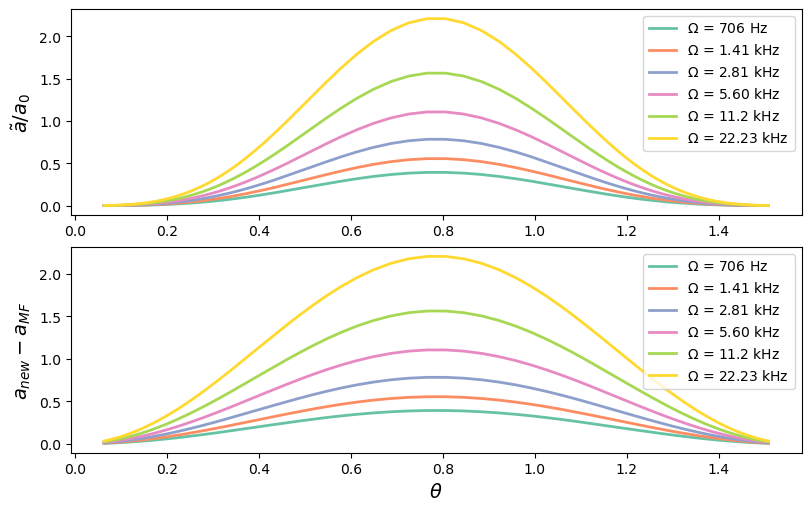

In [11]:
import numpy as np
import matplotlib.pyplot as plt

u = 1.66053906660e-27
m = 39*u
hbar = 1.054571818e-34 #J s

a_bohr = 0.52917721e-10
a11 = (86.4014*a_bohr); 
a22 = (33.2021*a_bohr);
a12 = (-53.1907*a_bohr);

#theta = np.linspace(0,np.pi/2,50)
Omega_values = [706, 1410, 2810, 5600, 11200, 22300]
a_bmf = np.ones(len(Omega_values))  # initialize vector to save the max of a_BMF (for delta=0)

d = np.linspace(-8,8,200)

labels = [r'$\Omega$ = 706 Hz', r'$\Omega$ = 1.41 kHz', r'$\Omega$ = 2.81 kHz', r'$\Omega$ = 5.60 kHz', r'$\Omega$ = 11.2 kHz',r'$\Omega$ = 22.23 kHz']
colors = plt.get_cmap('Set2').colors
lw =2

fig, ax = plt.subplots(2,1,constrained_layout=True, figsize=(8,5))
for i, Om in enumerate(Omega_values):
    Om = Om * 2*np.pi
    delta = d*Om
    Om_tilde = np.sqrt(delta**2+Om**2)
    lOm = np.sqrt(hbar/(m*Om_tilde))
    P = delta/Om_tilde
    theta = np.arccos(np.sqrt((1+P)/2))
    
    a_tilde = 2**0.5*(np.sin(theta)*np.cos(theta))**4/lOm * (a11+a22-2*a12)**2
    a_bmf[i] = np.max(a_tilde/a_bohr)  # save the max value of the BMf corrections (at delta = 0)
    
    ax[0].plot(theta, a_tilde/a_bohr, label=labels[i], lw=lw, color=colors[i])
    print(a_bmf[i])
    
ax[0].legend()
ax[0].set_ylabel(r'$\tilde{a}/a_0$',fontsize = 14)
    
print()
#%% MF 
for i, Om in enumerate(Omega_values):
    Om = Om * 2*np.pi
    delta = d*Om
    Om_tilde = np.sqrt(delta**2+Om**2)
    P = delta/Om_tilde
    theta = np.arccos(np.sqrt((1+P)/2))
    
    a_mm = a11*(np.sin(theta))**4 + a22*(np.cos(theta))**4 + 0.5*a12*(np.sin(2*theta))**2;
    a12_new = a12 + 2 * a_bmf[i]*a_bohr                                 # modify a12 so to consider the bmf shift
    a_mm_new = a11*(np.sin(theta))**4 + a22*(np.cos(theta))**4 + 0.5*a12_new*(np.sin(2*theta))**2;
    a = a_mm_new - a_mm
    #print(np.max(a/a_bohr))
    
    ax[1].plot(theta,a/a_bohr, label=labels[i], lw=lw, color=colors[i])   #plot the difference between a_mm - a_mm modified

ax[1].legend()
ax[1].set_xlabel(r'$\theta$', fontsize=14)
ax[1].set_ylabel(r'$a_{new} - a_{MF}$' ,fontsize = 14)

## Effects of FORT2 off on the kinetic energy

The fact that we cut FORT2 during the RF adiabatic sweep so to minimize the energy a at the minimum of $a_{--}$ (for detuning close to 0) may produce some excitation along the sweep. In addiction the effect may be different for each curve at different $\Omega$. Indeed for low $\Omega$ the BMF correction to the energy is small, while for high Rabi frequencies the minimum of the $E_{int}$ is shifted up. That means that the timing at which the axial trap is turned off is chosen accordingly to the $\Omega$. For the low Rabi frequency curve, the trap is turned off sooner then for the high Rabi frequency curve.

We already tried to extimate the error in energy given by FORT2 off: $$6 Hz/ms^2$$
So if we are off of 3 ms, the error would be of about $$6 Hz/ms^2 * (3ms)^2 = 54 Hz$$

### Effects on the energy
For example, for $\delta \gg 0$ we should not turn off the axial trap (FORT2). Since we turn it off at a certain point that means that the cloud will have a tendency to expand a bit between $\delta \gg 0 $ and $\delta =0$. This effect will be more pronunced for the low frequency curve.

From GPELab we know the energy. We have the energy as a funcion of time (as a function of the detuning) and we know when we turn off FORT 2. 

The potential energy per atom depends on the size $\sigma_z$ <br>

$$ U(\sigma_z) =\frac{1}{2} m\omega_{z}^2 \sigma_z^2 + \frac{E(\sigma_z,\delta)}{N} $$

And so the force is

$$F = -\nabla U = -m\omega_{z}^2\sigma_z - \frac{1}{N} \frac{\partial E}{\partial \sigma_z}$$

$$\frac{\partial E}{\partial \sigma_z} = \frac{\partial E}{\partial n_0}\frac{\partial n_0}{\partial \sigma_z}$$

$\frac{\partial E}{\partial \sigma_z}$ tells us how much the cloud has a tenedency to expand or not, and it is like a force driving for expension/repulsion:<br>
- $\frac{\partial E}{\partial \sigma_z}<0$, an increase of size recuces $E$. The clouds prefers to expand (repulsive force)<br>
- $\frac{\partial E}{\partial \sigma_z}>0$, an increase of size increases $E$. The clouds prefers to shrink (attractive force)<br>

I could run the simulation for two different $n_0$ so to calculate $\frac{\partial E}{\partial n_0}\sim \frac{\Delta E}{\Delta n_0}$. <br>

For a gaussian BEC in dimension d, the density is given by $n_0 = 1/(\pi\sigma^2)^{d/2}$, so

$$\frac{\partial n_0}{\partial \sigma_z} =  - d \frac{n_0}{\sigma_z}$$ 

So the force is:

$$F = -m\omega_{z}^2\sigma_z - \frac{1}{N} \frac{\Delta E}{\Delta n_0} \left(- d \frac{n_0}{\sigma_z}\right)$$

The first term is negative and the second term is positive. What one finds is that the force is larger at the beginning end is lower at $\delta=0$. Turning off FORT 2 at a gertain time, gives the opportunity to recuce the negative term in the force. <br>

Once evaluated the force we can integrate to get the velocity:

$$ \Delta v = \frac{1}{m}\int F dt $$

Finally the idea is to compare the kinetic energy that we calculate in that way ($E_{kin} = 1/2 m \Delta v^2$ assuming full adiabatic sweep) with the total kinetic energy we have.



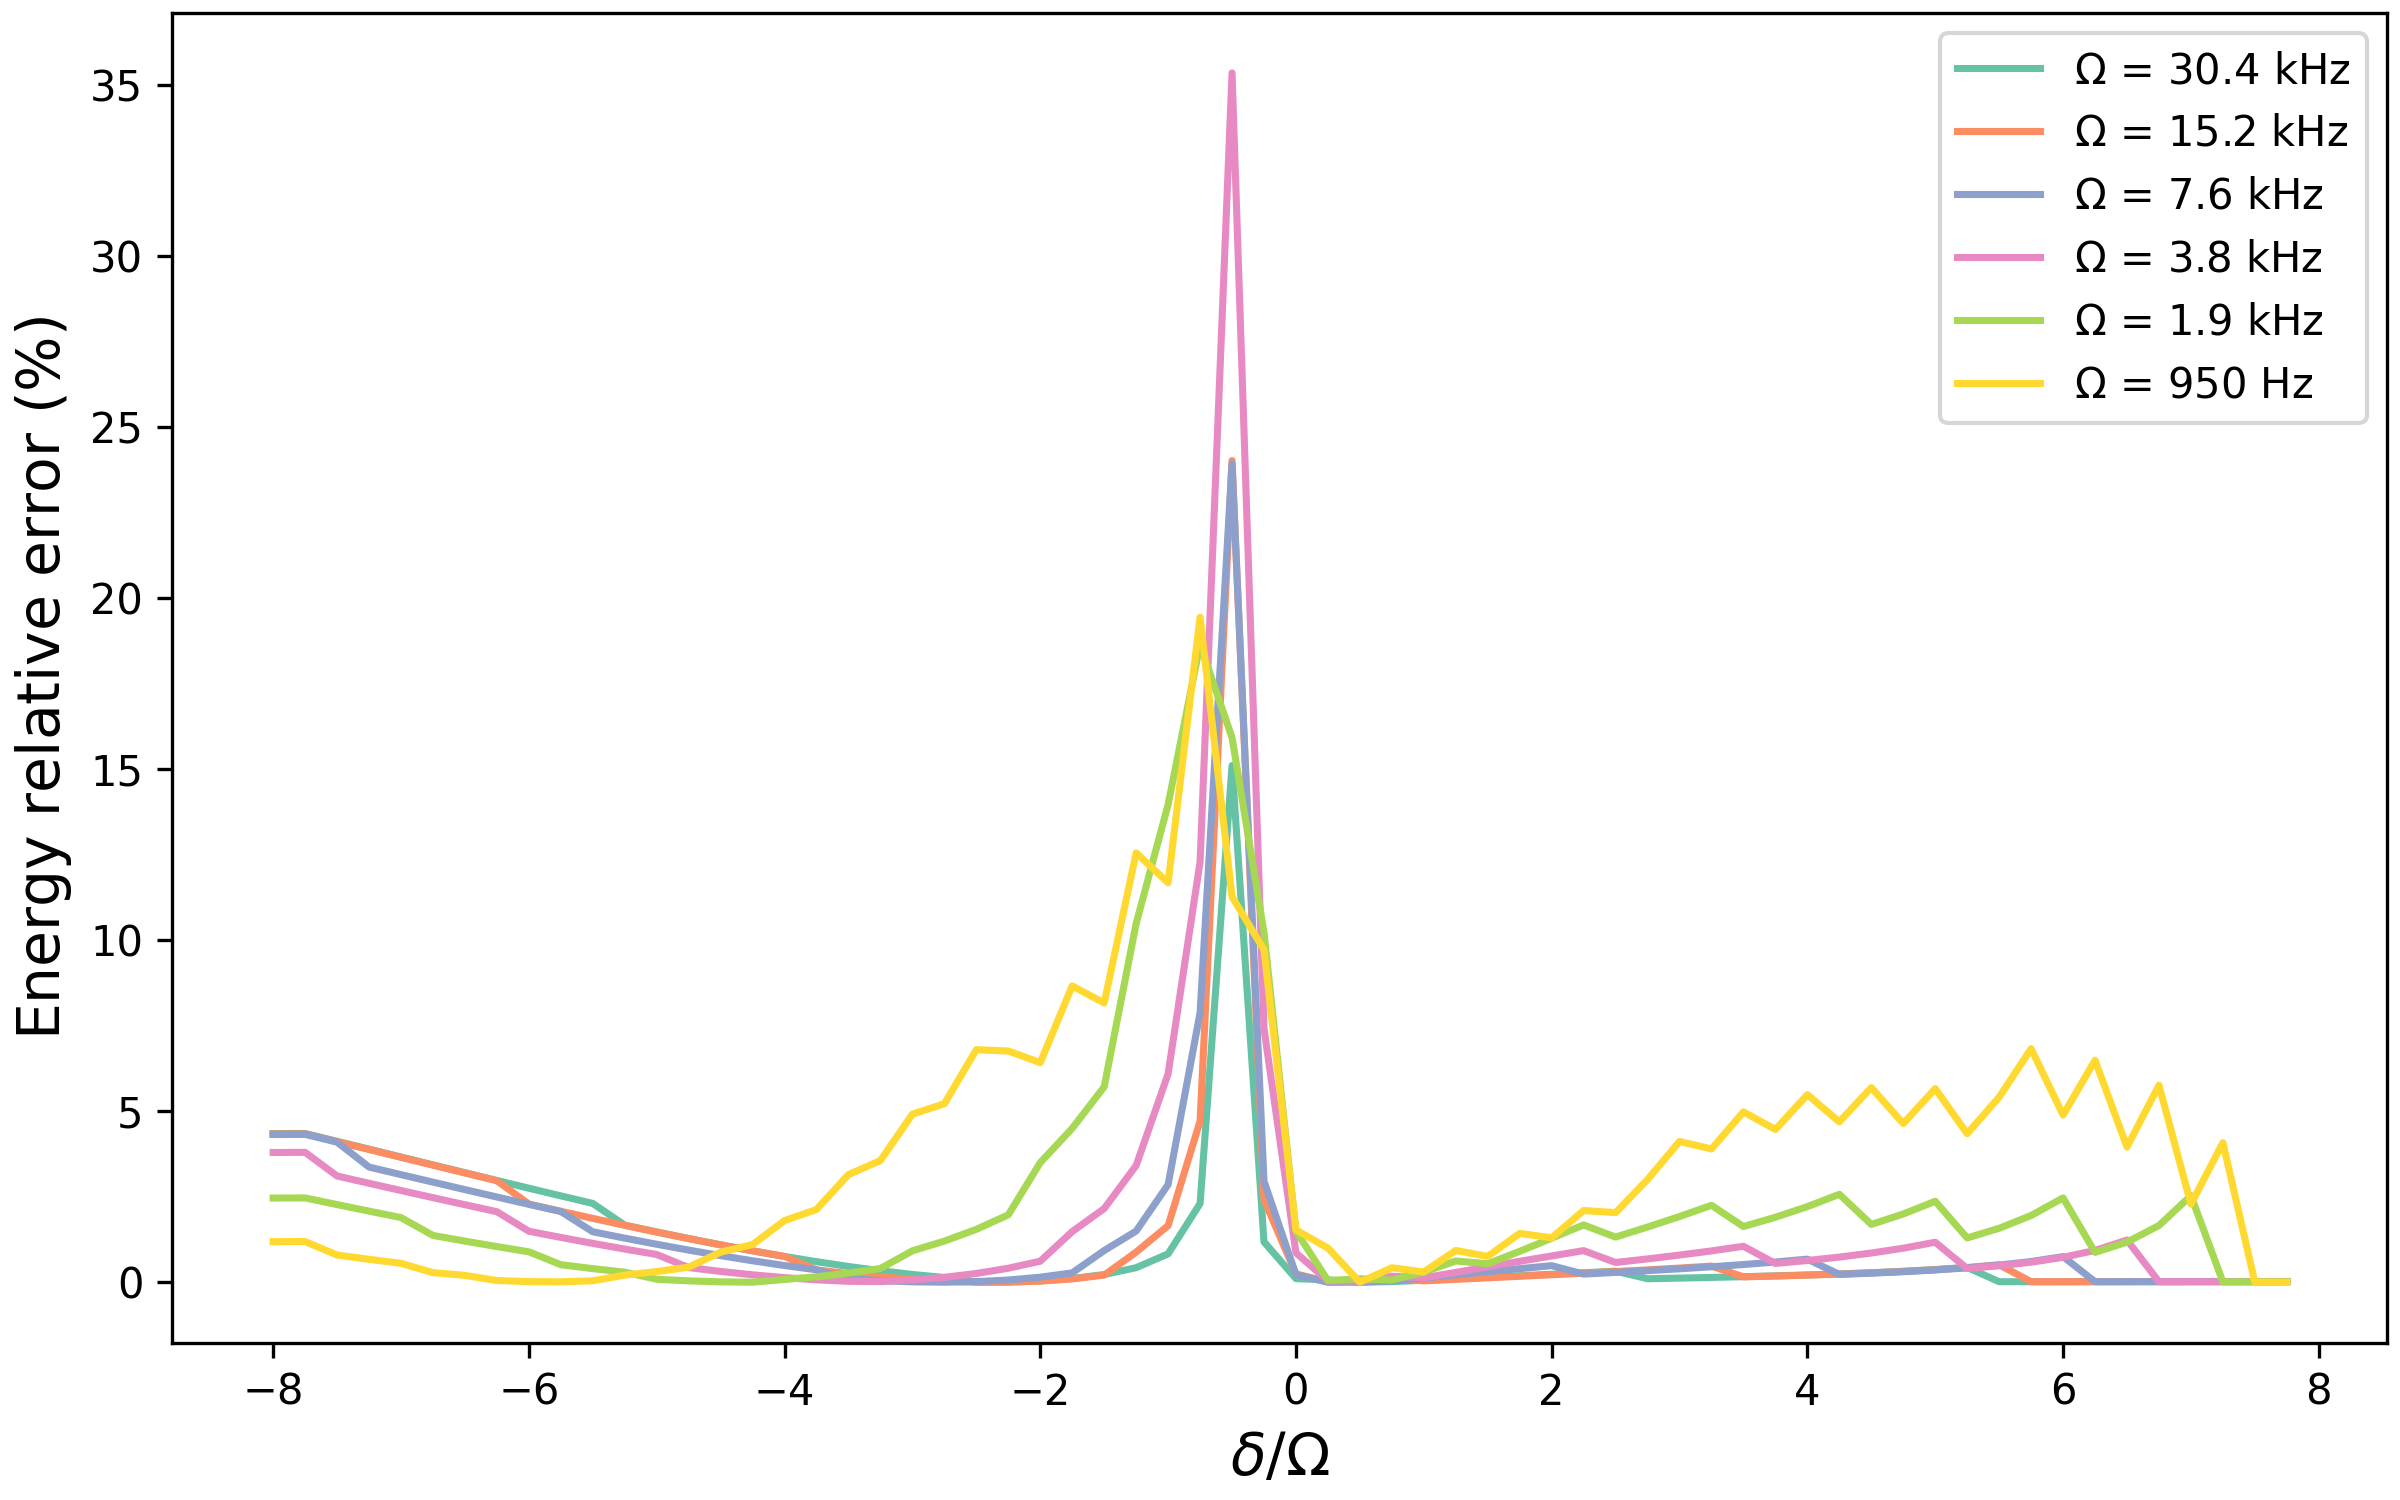

In [4]:
from IPython.display import display, Image
fileName = r"C:\Users\Sarah\Documents\GitHub\Numerical-simulations\GPELab\plot_code\FORT2 off - error\Figures\FORT2off-error.png"
display(Image(filename=fileName))